# Lesson 0: Introduction to Gymnasium

This lesson is about learning the basic RL interface before we train anything.

In normal PyTorch supervised learning, your data already exists: images, labels, text, targets, etc. In reinforcement learning, the data is created by interaction. The agent takes an action, the environment changes, and the agent receives reward feedback.

By the end of this notebook, you should understand:

- what an environment is
- what observations/states are
- what actions are
- what rewards are
- what `reset()` and `step()` do
- why `terminated` and `truncated` replaced the old `done` API
- how wrappers modify environments
- what a basic RL episode loop looks like


## 1) Setup

The original tutorial used old OpenAI Gym. The maintained modern version is Gymnasium, from the Farama Foundation.

The important import is:

```python
import gymnasium as gym
```

We install the classic-control environments first because they are lightweight and beginner-friendly. Atari support is optional because it needs extra packages and ROM handling.


In [1]:
%matplotlib inline
%pip install -U "gymnasium[classic-control]"

# Optional for the Atari cells later in this notebook:
# %pip install -U "gymnasium[atari]" "gymnasium[accept-rom-license]"

import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium.envs.registration import registry

print(gym.__version__)


Matplotlib is building the font cache; this may take a moment.


You should consider upgrading via the '/Users/hassaan/Projects/interview/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
1.1.1


## 2) Finding Available Environments

Gymnasium has a registry of environments. An environment is a task/world the agent can interact with.

Examples:

- `CartPole-v1`: balance a pole by moving a cart left or right
- `Pendulum-v1`: swing a pendulum upright with continuous torque
- `ALE/Pong-v5`: Atari Pong through the Arcade Learning Environment

The registry is useful when you want to see what environment IDs are available to pass into `gym.make(...)`.


In [2]:
env_ids = sorted(registry.keys())

print(f'There are {len(env_ids)} registered Gymnasium environments. Such as {env_ids[:12]}')


There are 62 registered Gymnasium environments. Such as ['Acrobot-v1', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'Blackjack-v1', 'CarRacing-v3', 'CartPole-v0', 'CartPole-v1', 'CliffWalking-v0']


Official environment index: https://gymnasium.farama.org/environments/

For Lesson 0, the best environment to start with is CartPole because the state is just a small vector and the action space is only two choices.

CartPole docs: https://gymnasium.farama.org/environments/classic_control/cart_pole/


## 3) Discrete Action Space Example: CartPole

`gym.make("CartPole-v1")` creates the environment.

CartPole is simple:

- the agent sees 4 numbers describing the cart and pole
- the agent chooses one of 2 actions
- reward is usually `+1` for every timestep the pole stays balanced
- the episode ends if the pole falls too far, the cart moves too far, or the time limit is reached

This is a perfect first RL environment because you can focus on the loop instead of image processing or complicated physics.


In [3]:
env = gym.make('CartPole-v1')


### Observation Space

The observation is what the agent sees at the current moment.

For CartPole, the observation is a continuous vector with 4 values:

```text
[cart_position, cart_velocity, pole_angle, pole_angular_velocity]
```

In PyTorch terms, this will eventually become the input features to your neural network.

The code below asks:

- is the observation discrete or continuous?
- what shape is it?
- what are the approximate min/max values?


In [4]:
print('observation space is:', env.observation_space)

print('is observation space discrete?', isinstance(env.observation_space, gym.spaces.Discrete))
print('is observation space continuous?', isinstance(env.observation_space, gym.spaces.Box))

print('observation space shape:', env.observation_space.shape)

print('observation space high values?', env.observation_space.high)
print('observation space low values?', env.observation_space.low)


observation space is: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
is observation space discrete? False
is observation space continuous? True
observation space shape: (4,)
observation space high values? [4.8               inf 0.41887903        inf]
observation space low values? [-4.8               -inf -0.41887903        -inf]


### Action Space

The action is what the agent is allowed to do.

For CartPole, the action space is `Discrete(2)`, which means there are exactly two valid actions:

```text
0 = push cart left
1 = push cart right
```

This matters because the model output should match the action space. For CartPole, a policy network often outputs two logits/probabilities, one for each action.


In [7]:
print('action space is:', env.action_space)

print('is action space discrete?', isinstance(env.action_space, gym.spaces.Discrete))
print('is action space continuous?', isinstance(env.action_space, gym.spaces.Box))

print('action space shape:', env.action_space.n)


action space is: Discrete(2)
is action space discrete? True
is action space continuous? False
action space shape: 2


### Environment Metadata

Every environment also has metadata/specification values.

For CartPole, these tell us things like:

- the max number of steps in an episode
- the reward threshold considered solved
- whether the environment is marked nondeterministic

You do not need to memorize these. The important habit is learning to inspect an environment before building a model for it.


In [8]:
print(env.spec.max_episode_steps)
print(env.spec.reward_threshold)
print(env.spec.nondeterministic)


500
475.0
False


## 4) Continuous Action Space Example: Pendulum

Not every environment has simple integer actions.

`Pendulum-v1` uses continuous actions. Instead of choosing action `0` or `1`, the agent chooses a floating point torque value.

This changes the kind of model you need:

- discrete actions often use categorical policies or Q-values
- continuous actions often use Gaussian policies or direct continuous outputs

You do not need to master continuous control yet. The goal here is just to recognize the difference.


In [9]:
env = gym.make('Pendulum-v1')


### Pendulum Observation Space

Pendulum observations are still continuous numbers, but they describe a different physical system.

The general lesson: always inspect `env.observation_space` before deciding your model input shape.


In [11]:
print('observation space is:', env.observation_space)

print('is observation space discrete?', isinstance(env.observation_space, gym.spaces.Discrete))
print('is observation space continuous?', isinstance(env.observation_space, gym.spaces.Box))

print('observation space shape:', env.observation_space.shape)

print('observation space high values?', env.observation_space.high)
print('observation space low values?', env.observation_space.low)


observation space is: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
is observation space discrete? False
is observation space continuous? True
observation space shape: (3,)
observation space high values? [1. 1. 8.]
observation space low values? [-1. -1. -8.]


### Pendulum Action Space

The action space is a `Box`, not `Discrete`.

That means the action is a continuous value, usually represented as a NumPy array. The `low` and `high` values tell you the valid range.


In [12]:
print('action space is:', env.action_space)

print('is action space discrete?', isinstance(env.action_space, gym.spaces.Discrete))
print('is action space continuous?', isinstance(env.action_space, gym.spaces.Box))

print('action space shape:', env.action_space.shape)

print('action space high values?', env.action_space.high)
print('action space low values?', env.action_space.low)


action space is: Box(-2.0, 2.0, (1,), float32)
is action space discrete? False
is action space continuous? True
action space shape: (1,)
action space high values? [2.]
action space low values? [-2.]


In [13]:
print(env.spec.max_episode_steps)
print(env.spec.reward_threshold)
print(env.spec.nondeterministic)


200
None
False


## 5) Atari Environments

Atari environments are different because the observation is usually an image frame, not a small vector.

That means:

- CartPole/Pendulum can use simple MLPs
- Atari usually needs CNNs
- preprocessing becomes important: resizing, grayscale, frame stacking, reward clipping, etc.

Modern Atari environment IDs use the `ALE/...-v5` namespace.

Examples:

```python
gym.make('ALE/Pong-v5')
gym.make('ALE/Freeway-v5')
gym.make('ALE/Freeway-v5', frameskip=1, repeat_action_probability=0.0)
```

Atari examples require optional dependencies:

```python
%pip install -U "gymnasium[atari]" "gymnasium[accept-rom-license]"
```

Docs:

- Gymnasium Atari: https://gymnasium.farama.org/environments/atari/
- ALE environments: https://ale.farama.org/environments/


In [17]:
%pip install -U "gymnasium[atari]" "gymnasium[accept-rom-license]"

import ale_py
import gymnasium as gym

# This line is often required to "kickstart" the registration in some versions
gym.register_envs(ale_py) 

env = gym.make('ALE/Freeway-v5')


Note: you may need to restart the kernel to use updated packages.


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


### Atari Observation Space

The observation space should look like an image shape, for example height, width, and color channels.

This is your first hint that the model architecture may need to change from a dense network to a convolutional network.


In [18]:
print('observation space is:', env.observation_space)
print('is observation space discrete?', isinstance(env.observation_space, gym.spaces.Discrete))
print('is observation space continuous?', isinstance(env.observation_space, gym.spaces.Box))
print('observation space shape:', env.observation_space.shape)


observation space is: Box(0, 255, (210, 160, 3), uint8)
is observation space discrete? False
is observation space continuous? True
observation space shape: (210, 160, 3)


### Atari Action Space

Atari actions are usually discrete, but the meanings depend on the game.

`get_action_meanings()` is useful because action `1` might mean `FIRE` in one game and something else in another.


In [19]:
print('action space is:', env.action_space)
print('action space shape:', env.action_space.n)
print('is action space discrete?', isinstance(env.action_space, gym.spaces.Discrete))
print('is action space continuous?', isinstance(env.action_space, gym.spaces.Box))
print('action meanings:', env.unwrapped.get_action_meanings())


action space is: Discrete(3)
action space shape: 3
is action space discrete? True
is action space continuous? False
action meanings: ['NOOP', 'UP', 'DOWN']


In [20]:
print(env.spec.max_episode_steps)
print(env.spec.reward_threshold)
print(env.spec.nondeterministic)


None
None
False


## 6) Wrappers

A wrapper is a clean way to modify an environment without changing the original environment code.

Common wrapper jobs:

- change observations before the agent sees them
- change rewards before the agent learns from them
- change actions before they reach the environment
- add logging or monitoring

This is very common in RL because raw environments often need preprocessing.

Current wrapper docs: https://gymnasium.farama.org/api/wrappers/


### Reward Wrapper

`ClipRewardEnv` changes the reward using `np.sign(reward)`.

That maps rewards into:

```text
positive reward -> +1
zero reward     ->  0
negative reward -> -1
```

Why do this? In some Atari games, reward scales can vary a lot. Clipping makes the learning signal simpler and more stable, especially in beginner DQN-style setups.

### Observation Wrapper

`ScaledFloatFrame` changes image pixels from integer values in `[0, 255]` to float values in `[0.0, 1.0]`.

This is the same kind of normalization you already know from computer vision work in PyTorch.


In [21]:
class ClipRewardEnv(gym.RewardWrapper):
    def __init__(self, env):
        super().__init__(env)

    def reward(self, reward):
        """Bin reward to {+1, 0, -1} by its sign."""
        return np.sign(reward)


class ScaledFloatFrame(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=0.0,
            high=1.0,
            shape=env.observation_space.shape,
            dtype=np.float32,
        )

    def observation(self, observation):
        return np.asarray(observation, dtype=np.float32) / 255.0


### Applying Wrappers

Wrappers are applied by reassigning `env`.

The order matters. Here the raw Pong environment is created first, then reward clipping is added, then observation scaling is added.

After this, every call to `env.step(...)` goes through the wrappers.


In [22]:
env = gym.make('ALE/Pong-v5')

env = ClipRewardEnv(env)
env = ScaledFloatFrame(env)


## 7) Interacting With an Environment

This is the most important part of Lesson 0.

In RL, you repeatedly do this:

1. reset the environment to start an episode
2. observe the current state
3. choose an action
4. send the action to the environment with `step(action)`
5. receive the next state, reward, and episode-ending flags

The environment is the thing generating your training data.


### Reset

`reset(seed=1234)` starts a fresh episode and makes the initial randomness reproducible.

Modern Gymnasium returns two things:

```python
state, info = env.reset(seed=1234)
```

- `state`: the first observation
- `info`: extra environment-specific metadata


In [23]:
env = gym.make('CartPole-v1')

state, info = env.reset(seed=1234)

print('state type:', type(state))
print('state shape:', state.shape)
print('state:', state)
print('info:', info)


state type: <class 'numpy.ndarray'>
state shape: (4,)
state: [ 0.04766998 -0.01198043  0.04232462 -0.02383076]
info: {}


CartPole state meaning:

```text
[cart_position, cart_velocity, pole_angle, pole_angular_velocity]
```

This vector is what your model will eventually use to decide whether to push left or right.

Docs: https://gymnasium.farama.org/environments/classic_control/cart_pole/#observation-space


### Sampling a Random Action

Before training a real agent, it is useful to sample random actions.

This does not learn anything. It just proves that the environment works and helps you understand the action format.


In [24]:
action = env.action_space.sample() # select random action

print('selected action:', action)


selected action: 0


For CartPole:

```text
0 = push cart left
1 = push cart right
```

Docs: https://gymnasium.farama.org/environments/classic_control/cart_pole/#action-space


### Step

`env.step(action)` applies the action and advances the environment by one timestep.

Modern Gymnasium returns five values:

```python
next_state, reward, terminated, truncated, info = env.step(action)
```

Meaning:

- `next_state`: what the agent sees after the action
- `reward`: feedback for this transition
- `terminated`: the task naturally ended, like the pole falling
- `truncated`: the episode was stopped by a limit, like max timesteps
- `info`: extra metadata

For simple loops, you can combine the ending flags:

```python
done = terminated or truncated
```


In [25]:
next_state, reward, terminated, truncated, info = env.step(action) # perform action in environment
done = terminated or truncated

print('next state:', next_state)
print('reward:', reward)
print('terminated:', terminated)
print('truncated:', truncated)
print('done:', done)
print('info:', info)


next state: [ 0.04743037 -0.207683    0.04184801  0.28189993]
reward: 1.0
terminated: False
truncated: False
done: False
info: {}


## 8) Interacting With an Atari Environment

Atari follows the same `reset()` and `step()` pattern, but the observations are image frames.

This section is conceptually useful even if you skip running it for now because Atari setup can require extra dependencies.


In [27]:
env = gym.make('ALE/Freeway-v5', frameskip=1, repeat_action_probability=0.0)

state, info = env.reset(seed=1234)

print('state type:', type(state))
print('state shape:', state.shape)
print('info:', info)


state type: <class 'numpy.ndarray'>
state shape: (210, 160, 3)
info: {'lives': 0, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (np.uint32(2906597030), np.uint32(1602421836))}


Because the state is an image, we can display it with Matplotlib.

This is the visual observation the agent would receive.


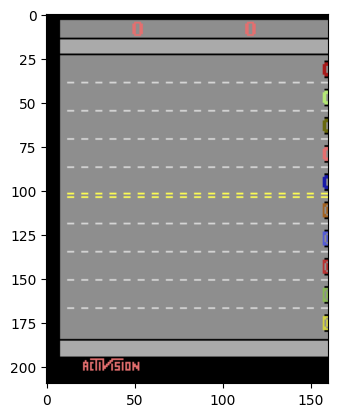

In [28]:
plt.imshow(state);


Again, we can sample a random action. For Atari, it helps to print the action meaning so the integer is not mysterious.


In [29]:
action = env.action_space.sample() # select random action

print('selected action:', action)
print('action meaning:', env.unwrapped.get_action_meanings()[action])


selected action: 0
action meaning: NOOP


In [30]:
next_state, reward, terminated, truncated, info = env.step(action) # perform action in environment
done = terminated or truncated

print('reward:', reward)
print('terminated:', terminated)
print('truncated:', truncated)
print('done:', done)
print('info:', info)


reward: 0.0
terminated: False
truncated: False
done: False
info: {'lives': 0, 'episode_frame_number': 1, 'frame_number': 1}


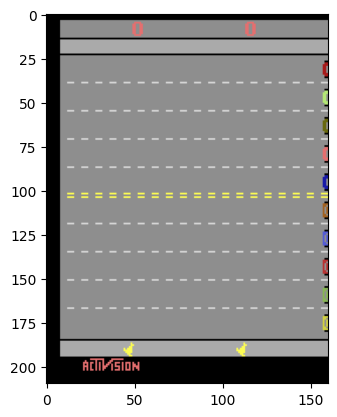

In [31]:
plt.imshow(next_state);


Here we manually choose the `UP` action and repeat it for 50 frames.

This is not learning yet. It is just controlled interaction with the environment.

Notice the pattern is still the same:

```python
state, reward, terminated, truncated, info = env.step(action)
```


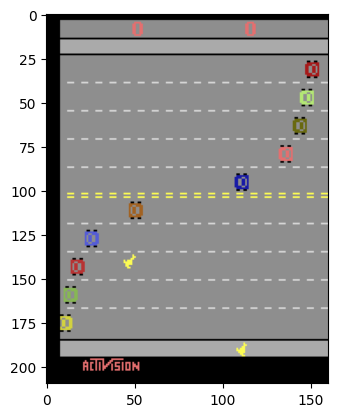

In [32]:
up_action = env.unwrapped.get_action_meanings().index('UP')

for i in range(50):
    state, reward, terminated, truncated, info = env.step(up_action)
    if terminated or truncated:
        state, info = env.reset()
        break

plt.imshow(state);


## 9) Full Reinforcement Learning Loop

This final example runs multiple episodes with random actions.

This is the skeleton of almost every RL algorithm:

1. reset environment
2. set episode reward to zero
3. while episode is not over:
   - choose action
   - step environment
   - collect reward
   - move to next state
4. report total episode reward

A learning algorithm adds model prediction and optimization inside this loop. But the environment interaction structure stays the same.


In [33]:
env = gym.make('ALE/SpaceInvaders-v5', frameskip=1, repeat_action_probability=0.0)

n_episodes = 10

for episode in range(n_episodes):

    episode_reward = 0
    terminated = False
    truncated = False
    state, info = env.reset(seed=1234 + episode)

    while not (terminated or truncated):

        action = env.action_space.sample()

        state, reward, terminated, truncated, info = env.step(action)

        episode_reward += reward

    print(f'episode: {episode+1}, reward: {episode_reward}')


episode: 1, reward: 210.0
episode: 2, reward: 355.0
episode: 3, reward: 75.0
episode: 4, reward: 50.0
episode: 5, reward: 120.0
episode: 6, reward: 50.0
episode: 7, reward: 135.0
episode: 8, reward: 50.0
episode: 9, reward: 210.0
episode: 10, reward: 105.0


## 10) Lesson 0 Mental Model

You are not training yet. You are learning the interface.

The whole lesson compresses to this:

```python
env = gym.make("SomeEnvironment-v0")
state, info = env.reset(seed=1234)

terminated = False
truncated = False

while not (terminated or truncated):
    action = choose_action(state)
    next_state, reward, terminated, truncated, info = env.step(action)
    state = next_state
```

Key takeaways:

- the environment generates experience
- the observation space tells you the model input shape
- the action space tells you the model output/action format
- reward is feedback, not a supervised label
- an episode ends when `terminated` or `truncated` becomes true
- wrappers are preprocessing layers around environments

Once this loop feels natural, Lesson 1 can replace random actions with a PyTorch policy network.


In [34]:
# Run `pip install "gymnasium[classic-control]"` for this example.
import gymnasium as gym

# Create our training environment - a cart with a pole that needs balancing
env = gym.make("CartPole-v1", render_mode="human")

# Reset environment to start a new episode
observation, info = env.reset()
# observation: what the agent can "see" - cart position, velocity, pole angle, etc.
# info: extra debugging information (usually not needed for basic learning)

print(f"Starting observation: {observation}")
# Example output: [ 0.01234567 -0.00987654  0.02345678  0.01456789]
# [cart_position, cart_velocity, pole_angle, pole_angular_velocity]

episode_over = False
total_reward = 0

while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)

    # reward: +1 for each step the pole stays upright
    # terminated: True if pole falls too far (agent failed)
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    episode_over = terminated or truncated

print(f"Episode finished! Total reward: {total_reward}")
env.close()

Starting observation: [-0.03925504  0.02328859  0.04550382  0.00946349]
Episode finished! Total reward: 14.0
